**Q1**

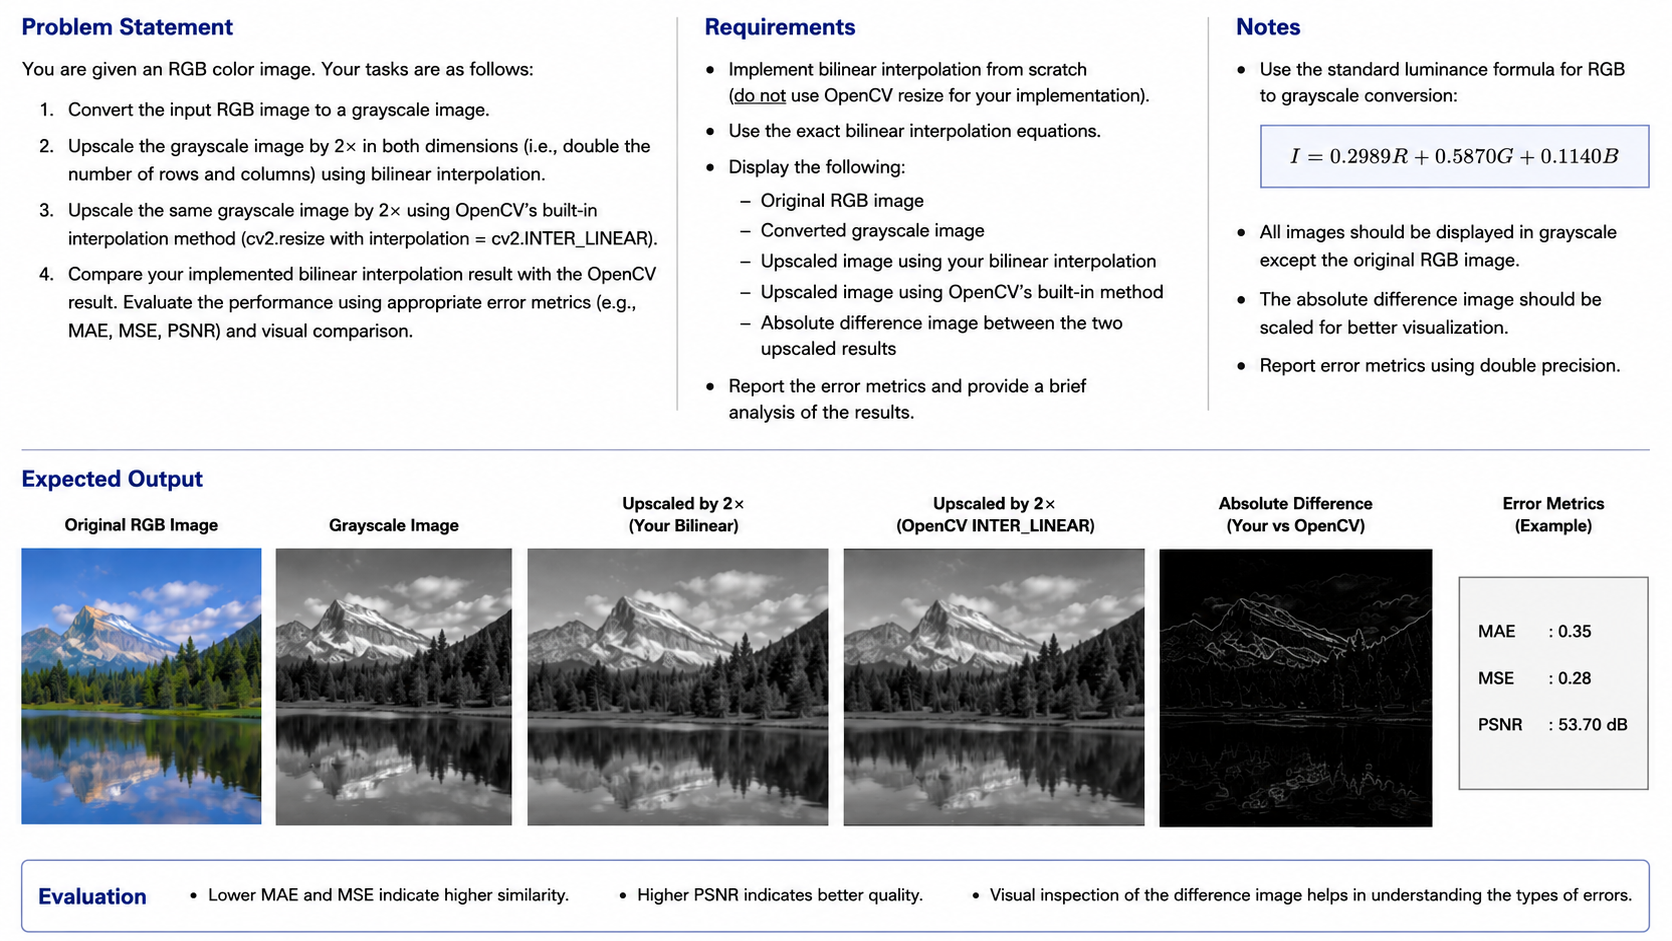

Complete the following code segments on the basis of the above questions.

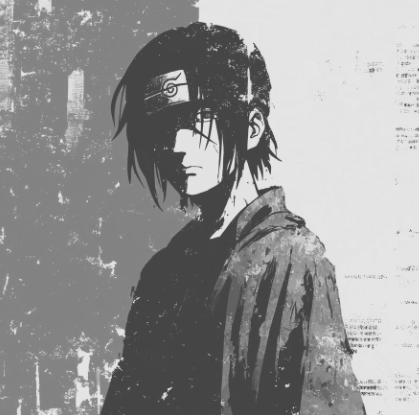

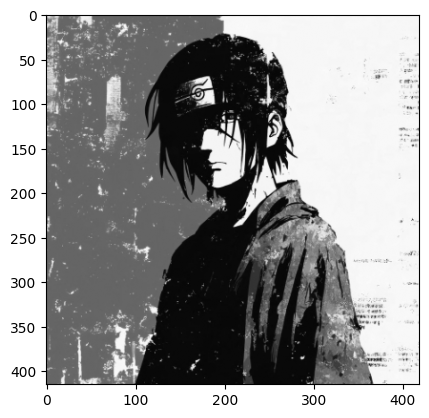

In [37]:
#import the libraries
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import cv2
#reading the image
image = cv2.imread('/content/itachi.png')

# Convert to grayscale image

b, g, r = cv2.split(image)
image_gray = 0.2989*r + 0.5870*g + 0.1140*b

height = image_gray.shape[0]
width = image_gray.shape[1]

h2 = 2 * height
w2 = 2 * width

image_gray.astype(np.uint16)

# show the image
cv2_imshow(image_gray)
plt.imshow(image_gray, cmap="gray")
plt.show()

In [44]:
import numpy as np
import cv2

def bilinear_resize_manual(your_image, new_h, new_w):
    h, w = your_image.shape[:2]
    output = np.zeros(new_w, new_h, dtype=your_image.dtype)
    for i in range(new_h):
      for j in range(new_w):
        x = (j+0.5) * (w/new_w) - 0.5
        y = (i+0.5) * (h/new_h) - 0.5

        x0 = int(np.floor(x))
        y0 = int(np.floor(y))

        dx = x - x0
        dy = y - y0

        x0 = max(0, min(x0, w - 2))
        y0 = max(0, min(y0, h - 2))
        x1 = x0 + 1
        y1 = y0 + 1
        A = your_image[y0, x0]
        B = your_image[y0, x1]
        C = your_image[y1, x0]
        D = your_image[y1, x1]

        top = A * dx + B * (1-dx)
        bottom = C * dx + D * (1-dx)
        pixel_value =  top * (1-dy) + bottom * dy
        output[i, j] = pixel_value.astype(your_image)

    return output.astype(your_image.dtype)


In [45]:
manual_out1 = bilinear_resize_manual(image_gray, h2, w2)
cv2_imshow(manual_out1)
plt.imshow(manual_out1, cmap='gray')

cv2_out1 = cv2.resize(image_gray, (w2,h2) , interpolation=cv2.INTER_LINEAR)
cv2_imshow(cv2_out1)
plt.imshow(cv2_out1,cmap='gray')

diff = manual_out1 - cv2_out1

cv2_imshow(diff_int16)

TypeError: argument for zeros() given by name ('dtype') and position (position 1)

**Q2. Write code to convert all JPG images in a folder to PNG**

In [35]:
import os
import cv2

input_dir = '/content/test/'
output_dir = 'output_png'

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through all files in input directory
for filename in os.listdir(input_dir):
    # Check if file is JPG
    if filename.endswith('.jpg') or filename.endswith('.jpeg'):
        # Full path of input image
        img_path = os.path.join(input_dir, filename)

        # Read image
        img = cv2.imread(img_path, cv2.COLOR_BGR2RGB)

        # Check if image was read successfully
        if img is not None:
            # Create PNG filename by replacing extension
            png_filename = os.path.splitext(filename)[0] + '.png'

            # Full path of output image
            png_path = os.path.join(output_dir, png_filename)

            # Write as PNG
            cv2.imwrite(png_path, img)